# Explorative Datenanalyse [Viertelstündliche Prognose des PV-Überschusses]

## 1.) Ziel der Analyse

### Hypothesen:
1. Hohe solare Einstrahlung führt nicht zwangsläufig zu einem hohen PV-Überschuss, da zeitgleich erhöhter Stromverbrauch den Überschuss reduziert. 
2. Modelle mit Wetter- und Einstrahlungsdaten prognostizieren den viertelstündlichen PV-Überschuss genauer als naive Prognosemethoden (z. B. „letzter gemessener Wert“ oder historischer Durchschnitt). 
3. Die Berücksichtigung zeitlicher Merkmale wie Uhrzeit und Wochentag verbessert die Prognose des viertelstündlichen PV-Überschusses. 
4. Nichtlineare Machine-Learning-Modelle sind besser geeignet zur Prognose des viertelstündlichen PV-Überschusses als lineare Regressionsmodelle.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PV-Daten
pv = pd.read_csv("../data/raw/pv_data.csv", sep=";", parse_dates=["timestamp"])
pv["timestamp"] = pd.to_datetime(pv["timestamp"])

pv.set_index("timestamp", inplace=True)

## 2.) Zeitumfang der Daten

Erwartung:
- 96 Werte pro Tag
- Prüfung auf fehlende Zeitpunkte

In [ ]:
start = pv.index.min()
end = pv.index.max()
dauer = end - start

print("Zeitraum:", start, "bis", end)
print("Gesamtdauer:", dauer)
print("Anzahl Viertelstunden:", len(pv))

pv.resample("15min").size()

## 3.) <span style="color:yellow">Deskriptive Statistik der Hauptkategorien
Analyse von:
- Solarproduktion
- Hausverbrauch

In [ ]:

# Solarproduktion und Hausverbrauch interessant
pv[['Solarproduktion', 'Hausverbrauch']].describe()

## für weather.csv (temperatur und bewölkung) und irradiance(ghi_cloudy_sky und ghi_clear_sky) auch einmal


## 4.) <span style="color:yellow">Grundlast-Analyse
Ziel: Die **Grundlast** (minimaler Hausverbrauch) schätzen,  
um aus der prognostizierten PV-Produktion die **verfügbare Überschuss-Energie** zu berechnen:

```
Verfügbare Energie = PV-Prognose − Grundlast
```

### 4.1.) Set-Up

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.data.preprocessing import load_pv_data
from src.data.splitting import time_series_split, split_summary
from src.features.feature_engineering import add_time_features

TARGET_PV   = "Solarproduktion"
TARGET_LOAD = "Hausverbrauch"
RESULTS_DIR = Path("../results/05_grundlast")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

### 4.2.) <span style="color:yellow">Hausverbrauch laden & visualisieren

Zeitraum: 2022-02-07 – 2025-06-16
Datenpunkte: 117,636  (15-min-Auflösung)

Hausverbrauch – Übersicht:
count    117636.00
mean        175.40
std         167.82
min           0.00
25%          82.00
50%         136.00
75%         201.00
max        4680.00
Name: Hausverbrauch, dtype: float64


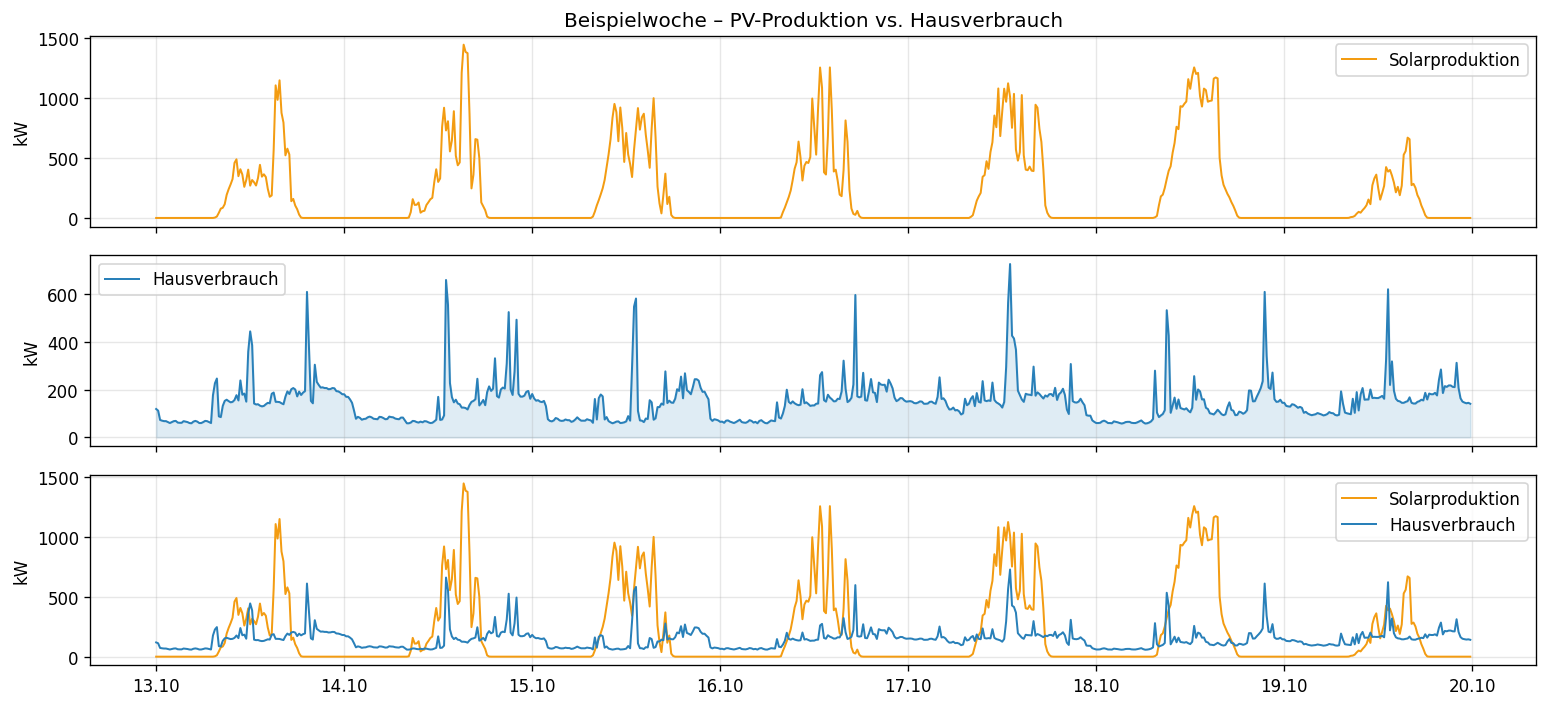

In [2]:
df = load_pv_data()
df = add_time_features(df)
print(f"Zeitraum: {df['timestamp'].min().date()} – {df['timestamp'].max().date()}")
print(f"Datenpunkte: {len(df):,}  (15-min-Auflösung)")

fig, axes = plt.subplots(3, 1, figsize=(13, 6), sharex=True)

# 7-Tage-Beispiel
start = df["timestamp"].iloc[len(df) // 2].floor("D")
mask  = (df["timestamp"] >= start) & (df["timestamp"] < start + pd.Timedelta(days=7))
sub   = df[mask].set_index("timestamp")

axes[0].plot(sub.index, sub[TARGET_PV],   color="#f39c12", linewidth=1.2, label="Solarproduktion")
axes[0].set_ylabel("kW"); axes[0].legend()
axes[0].set_title("Beispielwoche – PV-Produktion vs. Hausverbrauch")

axes[1].plot(sub.index, sub[TARGET_LOAD], color="#2980b9", linewidth=1.2, label="Hausverbrauch")
axes[1].fill_between(sub.index, 0, sub[TARGET_LOAD], alpha=0.15, color="#2980b9")
axes[1].set_ylabel("kW"); axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
axes[1].xaxis.set_major_locator(mdates.DayLocator())

print(f"\nHausverbrauch – Übersicht:")
print(df[TARGET_LOAD].describe().round(2))

axes[2].plot(sub.index, sub[TARGET_PV], color="#f39c12", linewidth=1.2, label="Solarproduktion")
axes[2].plot(sub.index, sub[TARGET_LOAD], color="#2980b9", linewidth=1.2, label="Hausverbrauch")
axes[2].set_ylabel("kW")
axes[2].legend()

plt.tight_layout()
plt.show()


## maybe nur 3. Diagramm zeigen, zeigt unsere Motivation

### 4.3.) Grundlast-Definition

> **Grundlast** = Verbrauch, der dauerhaft vorhanden ist (Kühlschrank, Standby, …).  
> Schätzmethode: **10. Perzentil** des Hausverbrauchs pro Stunde × Wochentag.  
> Robuster als Minimum (ignoriert kurzfristige Messfehler / Nullwerte).

In [ ]:
# Grundlast = 10. Perzentil des Hausverbrauchs je Stunde × Wochentag
# → robuster gegenüber Ausreißern als Minimum

PERCENTILE = 10  # anpassbar

grundlast = (
    df.groupby(["hour", "day_of_week"])[TARGET_LOAD]
    .quantile(PERCENTILE / 100)
    .rename("grundlast")
    .reset_index()
)

print(f"Grundlast-Schätzer ({PERCENTILE}. Perzentil pro Stunde × Wochentag):")
print(f"  Median: {grundlast['grundlast'].median():.2f} kW")
print(f"  Min:    {grundlast['grundlast'].min():.2f} kW")
print(f"  Max:    {grundlast['grundlast'].max():.2f} kW")

### 4.4.) Grundlast nach Stunde und Wochentag

In [ ]:
# Heatmap: Grundlast nach Stunde × Wochentag
pivot = grundlast.pivot(index="hour", columns="day_of_week", values="grundlast")
pivot.columns = ["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(
    pivot, ax=axes[0], cmap="YlOrRd", annot=True, fmt=".1f",
    linewidths=0.4, cbar_kws={"label": "kW"},
)
axes[0].set_title(f"Grundlast [{PERCENTILE}. Perz.] nach Stunde × Wochentag", fontsize=11)
axes[0].set_xlabel("Wochentag")
axes[0].set_ylabel("Stunde")

# Tagesprofil
for dow, name in [(0, "Werktag (Mo–Fr)"), (5, "Samstag"), (6, "Sonntag")]:
    sub = grundlast[grundlast["day_of_week"] == dow]
    axes[1].plot(sub["hour"], sub["grundlast"], marker="o", markersize=4, label=name)
axes[1].set_title("Grundlast-Tagesprofil nach Wochentag", fontsize=11)
axes[1].set_xlabel("Stunde")
axes[1].set_ylabel("Grundlast [kW]")
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.5.) Grundlast nach Stunde und Wochentag

In [ ]:
# Saisonaler Vergleich der Grundlast

season_map = {12: "Winter", 1: "Winter", 2: "Winter",
              3: "Spring", 4: "Spring", 5: "Spring",
              6: "Summer", 7: "Summer", 8: "Summer",
              9: "Autumn", 10: "Autumn", 11: "Autumn"}

df["season"] = df["timestamp"].dt.month.map(season_map)

season_order = ["Winter", "Spring", "Summer", "Autumn"]
season_colors = {"Winter": "#74b9ff", "Spring": "#55efc4",
                 "Summer": "#fdcb6e", "Autumn": "#e17055"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box-Plot: Hausverbrauch je Saison
data_by_season = [df[df["season"] == s][TARGET_LOAD].dropna() for s in season_order]
bp = axes[0].boxplot(data_by_season, labels=season_order, patch_artist=True,
                     medianprops={"color": "black", "linewidth": 2})
for patch, season in zip(bp["boxes"], season_order):
    patch.set_facecolor(season_colors[season])
    patch.set_alpha(0.7)
axes[0].set_ylabel("Hausverbrauch [kW]")
axes[0].set_title("Verteilung Hausverbrauch je Saison")

# Tagesprofil je Saison (Median)
for season in season_order:
    profile = (
        df[df["season"] == season]
        .groupby("hour")[TARGET_LOAD]
        .quantile(PERCENTILE / 100)
    )
    axes[1].plot(profile.index, profile.values, marker="o", markersize=3,
                 label=season, color=season_colors[season])
axes[1].set_xlabel("Stunde")
axes[1].set_ylabel(f"Grundlast [{PERCENTILE}. Perz., kW]")
axes[1].set_title("Grundlast-Tagesprofil je Saison")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Grundlast-Statistik je Saison:")
print(
    df.groupby("season")[TARGET_LOAD]
    .quantile(PERCENTILE / 100)
    .reindex(season_order)
    .round(2)
    .to_frame("Grundlast [kW]")
)

## 5.) <span style="color:yellow">Solarproduktion nach Stunde, Wochentag und Saison

### 5.1.) <span style="color:yellow">nach Stunde, Wochentag

In [ ]:
pv_hourly = (
    df.groupby(["day_of_week", "hour"])[TARGET_PV]
    .mean()
    .reset_index(name="solarproduktion")
)

pivot = pv_hourly.pivot(index="hour", columns="day_of_week", values="solarproduktion")
pivot.columns = ["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(
    pivot,
    ax=axes[0],
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",
    linewidths=0.4,
    cbar_kws={"label": "kW"},
)

axes[0].set_title("Solarproduktion nach Stunde × Wochentag", fontsize=11)
axes[0].set_xlabel("Wochentag")
axes[0].set_ylabel("Stunde")

# Tagesprofil
for dow, name in [(0, "Werktag (Mo–Fr)"), (5, "Samstag"), (6, "Sonntag")]:
    sub = pv_hourly[pv_hourly["day_of_week"] == dow]
    axes[1].plot(sub["hour"], sub["solarproduktion"], marker="o", markersize=4, label=name)

axes[1].set_title("Solarproduktion – Tagesprofil nach Wochentag", fontsize=11)
axes[1].set_xlabel("Stunde")
axes[1].set_ylabel("Solarproduktion [kW]")
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.2.) <span style="color:yellow">nach Saison


In [ ]:
# Saisonaler Vergleich der Solarproduktion

season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
}

df["season"] = df["timestamp"].dt.month.map(season_map)

season_order = ["Winter", "Spring", "Summer", "Autumn"]
season_colors = {
    "Winter": "#74b9ff",
    "Spring": "#55efc4",
    "Summer": "#fdcb6e",
    "Autumn": "#e17055"
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box-Plot: Solarproduktion je Saison
data_by_season = [df[df["season"] == s][TARGET_PV].dropna() for s in season_order]
bp = axes[0].boxplot(
    data_by_season,
    labels=season_order,
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 2}
)

for patch, season in zip(bp["boxes"], season_order):
    patch.set_facecolor(season_colors[season])
    patch.set_alpha(0.7)

axes[0].set_ylabel("Solarproduktion [kW]")
axes[0].set_title("Verteilung Solarproduktion je Saison")

# Tagesprofil je Saison
for season in season_order:
    profile = (
        df[df["season"] == season]
        .groupby("hour")[TARGET_PV]
        .quantile(PERCENTILE / 100)
    )
    axes[1].plot(
        profile.index,
        profile.values,
        marker="o",
        markersize=3,
        label=season,
        color=season_colors[season]
    )

axes[1].set_xlabel("Stunde")
axes[1].set_ylabel(f"Solarproduktion [{PERCENTILE}. Perz., kW]")
axes[1].set_title("Solarproduktions-Tagesprofil je Saison")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Solarproduktions-Statistik je Saison:")
print(
    df.groupby("season")[TARGET_PV]
    .quantile(PERCENTILE / 100)
    .reindex(season_order)
    .round(2)
    .to_frame("Solarproduktion [kW]")
)

## 6.) <span style="color:yellow">Gegenüberstellung Solarproduktion vs. Grundlast

### 6.1.) <span style="color:yellow">nach Saison
welches davon???

In [ ]:
# Kompakte Vergleichsgrafik: Tagesprofile von Grundlast und Solarproduktion je Saison

season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
}

df["season"] = df["timestamp"].dt.month.map(season_map)

season_order = ["Winter", "Spring", "Summer", "Autumn"]
season_colors = {
    "Winter": "#74b9ff",
    "Spring": "#55efc4",
    "Summer": "#fdcb6e",
    "Autumn": "#e17055"
}

plt.figure(figsize=(12, 6))

for season in season_order:
    profile_load = (
        df[df["season"] == season]
        .groupby("hour")[TARGET_LOAD]
        .quantile(PERCENTILE / 100)
    )
    profile_pv = (
        df[df["season"] == season]
        .groupby("hour")[TARGET_PV]
        .median()
    )

    plt.plot(
        profile_load.index, profile_load.values,
        linestyle="--", marker="o", markersize=3,
        color=season_colors[season], label=f"{season} – Grundlast"
    )
    plt.plot(
        profile_pv.index, profile_pv.values,
        linestyle="-", marker="o", markersize=3,
        color=season_colors[season], label=f"{season} – Solarproduktion"
    )

plt.xlabel("Stunde")
plt.ylabel("Leistung [kW]")
plt.title("Grundlast und Solarproduktion im saisonalen Tagesvergleich")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# Saisonaler Vergleich: Grundlast und Solarproduktion gemeinsam

season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
}

df["season"] = df["timestamp"].dt.month.map(season_map)

season_order = ["Winter", "Spring", "Summer", "Autumn"]
season_colors = {
    "Winter": "#74b9ff",
    "Spring": "#55efc4",
    "Summer": "#fdcb6e",
    "Autumn": "#e17055"
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ---------------------------------------------------
# 1) Boxplots: Grundlast und Solarproduktion je Saison
# ---------------------------------------------------
positions_load = [1, 4, 7, 10]
positions_pv   = [2, 5, 8, 11]

data_load = [df[df["season"] == s][TARGET_LOAD].dropna() for s in season_order]
data_pv   = [df[df["season"] == s][TARGET_PV].dropna() for s in season_order]

bp_load = axes[0].boxplot(
    data_load,
    positions=positions_load,
    widths=0.7,
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 1.8}
)

bp_pv = axes[0].boxplot(
    data_pv,
    positions=positions_pv,
    widths=0.7,
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 1.8}
)

# Farben setzen
for patch, season in zip(bp_load["boxes"], season_order):
    patch.set_facecolor(season_colors[season])
    patch.set_alpha(0.45)

for patch, season in zip(bp_pv["boxes"], season_order):
    patch.set_facecolor(season_colors[season])
    patch.set_alpha(0.85)

axes[0].set_xticks([1.5, 4.5, 7.5, 10.5])
axes[0].set_xticklabels(season_order)
axes[0].set_ylabel("Leistung [kW]")
axes[0].set_title("Verteilung von Grundlast und Solarproduktion je Saison")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="gray", alpha=0.45, label="Grundlast"),
    Patch(facecolor="gray", alpha=0.85, label="Solarproduktion")
]
axes[0].legend(handles=legend_elements)

# ---------------------------------------------------
# 2) Tagesprofile je Saison: beide Größen im Vergleich
# ---------------------------------------------------
for season in season_order:
    profile_load = (
        df[df["season"] == season]
        .groupby("hour")[TARGET_LOAD]
        .quantile(PERCENTILE / 100)
    )
    
    profile_pv = (
        df[df["season"] == season]
        .groupby("hour")[TARGET_PV]
        .median()
    )

    # Grundlast: gestrichelt
    axes[1].plot(
        profile_load.index,
        profile_load.values,
        linestyle="--",
        marker="o",
        markersize=3,
        color=season_colors[season],
        label=f"{season} – Grundlast"
    )

    # Solarproduktion: durchgezogen
    axes[1].plot(
        profile_pv.index,
        profile_pv.values,
        linestyle="-",
        marker="o",
        markersize=3,
        color=season_colors[season],
        label=f"{season} – Solarproduktion"
    )

axes[1].set_xlabel("Stunde")
axes[1].set_ylabel("Leistung [kW]")
axes[1].set_title("Tagesprofile von Grundlast und Solarproduktion je Saison")
axes[1].legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.show()

print("Saisonale Übersicht:")
summary = pd.DataFrame({
    "Grundlast [kW]": df.groupby("season")[TARGET_LOAD].quantile(PERCENTILE / 100),
    "Solarproduktion [kW]": df.groupby("season")[TARGET_PV].median()
}).reindex(season_order).round(2)

print(summary)

### 6.2.) <span style="color:yellow">nach Stunde, Wochentag


In [ ]:
# Wochentage gruppieren
def day_group(d):
    if d <= 4:
        return "Week"
    elif d == 5:
        return "Saturday"
    else:
        return "Sunday"

df["day_group"] = df["day_of_week"].apply(day_group)

day_order = ["Week", "Saturday", "Sunday"]

# --------------------------------------------------
# Grundlast aggregieren
# --------------------------------------------------
load_hourly = (
    df.groupby(["day_group", "hour"])[TARGET_LOAD]
    .quantile(PERCENTILE / 100)
    .reset_index(name="grundlast")
)

# --------------------------------------------------
# Solarproduktion aggregieren
# --------------------------------------------------
pv_hourly = (
    df.groupby(["day_group", "hour"])[TARGET_PV]
    .mean()
    .reset_index(name="solarproduktion")
)

# --------------------------------------------------
# Pivots für Heatmaps
# --------------------------------------------------
pivot_load = load_hourly.pivot(index="hour", columns="day_group", values="grundlast")
pivot_pv   = pv_hourly.pivot(index="hour", columns="day_group", values="solarproduktion")

pivot_load = pivot_load[day_order]
pivot_pv   = pivot_pv[day_order]

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Grundlast Heatmap
sns.heatmap(
    pivot_load,
    ax=axes[0],
    cmap="Blues",
    annot=True,
    fmt=".1f",
    linewidths=0.4,
    cbar_kws={"label": "kW"},
)
axes[0].set_title(f"Grundlast nach Stunde × Tagtyp\n({PERCENTILE}. Perzentil)")
axes[0].set_xlabel("Tagtyp")
axes[0].set_ylabel("Stunde")

# Solarproduktion Heatmap
sns.heatmap(
    pivot_pv,
    ax=axes[1],
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",
    linewidths=0.4,
    cbar_kws={"label": "kW"},
)
axes[1].set_title("Solarproduktion nach Stunde × Tagtyp")
axes[1].set_xlabel("Tagtyp")
axes[1].set_ylabel("Stunde")

# Vergleich Linienplot
for day in day_order:
    sub_load = load_hourly[load_hourly["day_group"] == day]
    sub_pv   = pv_hourly[pv_hourly["day_group"] == day]

    axes[2].plot(
        sub_load["hour"],
        sub_load["grundlast"],
        linestyle="--",
        marker="o",
        markersize=4,
        label=f"{day} Grundlast"
    )

    axes[2].plot(
        sub_pv["hour"],
        sub_pv["solarproduktion"],
        linestyle="-",
        marker="o",
        markersize=4,
        label=f"{day} Solar"
    )

axes[2].set_title("Tagesprofil: Grundlast vs. Solarproduktion")
axes[2].set_xlabel("Stunde")
axes[2].set_ylabel("Leistung [kW]")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

Aufgaben:

- PPP bearbeiten
